In [2]:
#%pip install torch torchvision torchaudio

In [13]:
#imports
import torch
import torch.nn as nn
import torch.optim as optim 
import numpy as np

import matplotlib.pyplot as plt
from IPython import display
import time 
import random
import os
from torch.quasirandom import SobolEngine

In [4]:
def set_seed(seed=250):
    # 1. Basic Python and OS
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy
    np.random.seed(seed)
    
    # 3. PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if using multi-GPU
    
    # 4. CuDNN (Ensures convolution/linear math is consistent)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(250) # You can pick any number

In [5]:
state_dim = 2
action_dim = 1


Output Torque Range is -2 to 2 in the gym environment


In [25]:
#Hyperparameters

alpha_critic = 1.0
beta_critic = 0.1
alpha_actor = 1.0
beta_actor = 0.5

lr_actor = 1e-3
lr_critic = 1e-3
batch_size = 5000
activation_fn = nn.SiLU #ReLu apparently causes dead gradients
layers = [128, 128]
k_max = 100 #outer loop
N_epochs = 50 #inner loop
gamma = 0.99
dt = 0.05

''' Arnav Q and R matrices 
Q = np.eye(state_dim)
R = np.eye(action_dim)

Q = torch.tensor(Q, dtype=torch.float32)
R = torch.tensor(R, dtype=torch.float32)

But gemini told me good Q and R matrices for pendulum problem, so am using those
'''
Q = torch.eye(2)   # 2x2 identity — penalizes x1^2 + x2^2
R = torch.tensor([[1.0]])  # scalar u^2 penalty
P = torch.eye(2, dtype=torch.float32)  # for Phase 1 W(x) = x^T P x

In [7]:
# x1_dot = -x1 + x2
# x2_dot = -0.5*x1 - 0.5*x2 + 0.5*x1^2*x2 + x1*u

def p_dynamics(x, u):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    dx1 = -x1 + x2
    dx2 = -0.5*x1 - 0.5*x2 + 0.5*(x1**2)*x2 + x1*u
    return torch.cat([dx1, dx2], dim=1)

In [8]:
# Initialising the Actor Critic Networks 

#critic network
critic = nn.Sequential(
    nn.Linear(state_dim, 128),
    nn.Tanh(),
    nn.Linear(128,128),
    nn.Tanh(),
    nn.Linear(128,1)
)

#actor network
actor = nn.Sequential(
    nn.Linear(state_dim, 128),
    nn.Tanh(),
    nn.Linear(128, 128),
    nn.Tanh(),
    nn.Linear(128,action_dim),
    nn.Tanh()  #torque is betweeb -1 and 1
)
opt_actor = torch.optim.Adam(actor.parameters(), lr=lr_actor)
opt_critic = torch.optim.Adam(critic.parameters(), lr=lr_critic)


#Scaling the torque, env requires torque between -2 and 2
def get_action(state_tensor, actor_net):
    raw_action = actor(state_tensor)
    return raw_action * 2.0


In [9]:
# Hamiltonian Function 
#Implements EQN 25 from paper | H = Integral(cost)dt + W(x_next) - W(x_now)
def get_integral_hamiltonian(x0, actor_net, dynamics_model, Q, R, P, dt=dt):
    u = get_action(x0, actor_net)
    # W(x_now) = x0^T * P * x0
    W_now = torch.bmm(x0.unsqueeze(1), torch.bmm(P.expand(x0.size(0), -1, -1), x0.unsqueeze(2))).squeeze()
    f_xu = dynamics_model(x0, u)
    x_next = x0 + f_xu * dt

    # W(x_next) = x_next^T * P * x_next
    W_next = torch.bmm(x_next.unsqueeze(1), torch.bmm(P.expand(x_next.size(0), -1, -1), x_next.unsqueeze(2))).squeeze()

    # Immediate Quadratic Cost: x^T Q x + u^T R u
    cost_instant = torch.bmm(x0.unsqueeze(1), torch.bmm(Q.expand(x0.size(0), -1, -1), x0.unsqueeze(2))).squeeze() + \
                    (u**2).squeeze() * R.item()

    # Approximation of the integral over dt
    integral_cost = cost_instant * dt

    # Equation (25)
    H = integral_cost + W_next - W_now
    return H

In [14]:
def sample_states(batch_size, boundary_ratio=0.3):
    sobol = SobolEngine(dimension=2, scramble=True)
    raw_samples = sobol.draw(batch_size)
    x = torch.zeros((batch_size, 2))
    x[:, 0] = (raw_samples[:, 0] * 2.0) - 1.0  # x1 in [-1, 1]
    x[:, 1] = (raw_samples[:, 1] * 2.0) - 1.0  # x2 in [-1, 1]
    if boundary_ratio > 0:
        n_boundary = int(batch_size * boundary_ratio)
        x[-n_boundary:, 0] = torch.where(x[-n_boundary:, 0] > 0, 1.0, -1.0)
        x[-n_boundary:, 1] = torch.where(x[-n_boundary:, 1] > 0, 1.0, -1.0)
    return x

In [15]:
# Setup phase 1

torch.manual_seed(250)
n_iterations = 1000 # Increased for better convergence
batch_size = 5000    # Nu in your equation
optimizer_p1 = torch.optim.Adam(actor.parameters(), lr=1e-3)

print("--- Starting Phase 1: Admissibility Training ---")

for i in range(n_iterations):
    # 1. Sample Nu states {xk}
    x_batch = sample_states(batch_size, boundary_ratio=0.3)
    x_batch = x_batch.to(torch.float32)
    x_batch.requires_grad_(True)
    
    # 2. Calculate Hamiltonian for the batch
    H = get_integral_hamiltonian(x_batch, actor, p_dynamics, Q, R, P)
    
    # 3. Equation (24): Minimize the positive violations (ReLU)
    # This forces H <= 0 across the entire state space
    loss = torch.mean(torch.relu(H))
    
    # 4. Backprop
    optimizer_p1.zero_grad()
    loss.backward()
    optimizer_p1.step()
    
    if i % 200 == 0:
        print(f"Iteration {i:4d} | Admissibility Loss: {loss.item():.8f}")

print("--- Phase 1 Complete ---")

--- Starting Phase 1: Admissibility Training ---
Iteration    0 | Admissibility Loss: 0.00548991
Iteration  200 | Admissibility Loss: 0.00183632
Iteration  400 | Admissibility Loss: 0.00182346
Iteration  600 | Admissibility Loss: 0.00182353
Iteration  800 | Admissibility Loss: 0.00181945
--- Phase 1 Complete ---


In [16]:
def collect_data(actor_net, num_steps=500, batch_size=100):
    states = []
    x = sample_states(batch_size)
    for _ in range(num_steps):
        with torch.no_grad():
            u = get_action(x, actor_net)
            f = p_dynamics(x, u)
            x = x + f * dt
            x = x.clamp(-1.5, 1.5)  # keep in bounded region
        states.append(x.clone())
    return torch.cat(states, dim=0)

In [17]:
# Phase 2

def train_phase2(data_buffer, actor, critic, opt_critic, Q, R, p_dynamics):
    critic.train()
    actor.eval() # Actor is fixed during Phase 2
    
    # Standard PIRL hyperparameter for Critic weight
    alpha_v = 1.0 
    
    # We run several inner iterations to let the Critic converge
    for _ in range(1000): 
        # 1. Sample a batch from the real data
        idx = torch.randperm(data_buffer.size(0))[:32]
        x = data_buffer[idx].requires_grad_(True)
        
        # 2. Get Actor's torque (fixed)
        u = get_action(x, actor).detach()
        
        # 3. Calculate Gradient of Value Function (dV/dx)
        V = critic(x)
        dVdx = torch.autograd.grad(V.sum(), x, create_graph=True)[0]
        
        # 4. HJB Residual: H = xTQx + uTRu + (dV/dx) * f(x,u)
        f_xu = p_dynamics(x, u)
        cost_instant = torch.sum((x @ Q) * x, dim=1, keepdim=True) + (u**2) * R
        H = cost_instant + torch.sum(dVdx * f_xu, dim=1, keepdim=True)
        
        # 5. Loss: Minimize H^2 (The Residual)
        loss_v = alpha_v * torch.mean(H**2)
        
        opt_critic.zero_grad()
        loss_v.backward()
        opt_critic.step()
        
    return loss_v.item()

In [18]:
#  Phase 3 

def train_phase3(data_buffer, actor, critic, opt_actor, Q, R, p_dynamics, beta_u=0.5):
    actor.train()
    critic.eval() # Critic is fixed during Phase 3
    
    for _ in range(100):
        idx = torch.randperm(data_buffer.size(0))[:32]
        x = data_buffer[idx].requires_grad_(True)
        
        # 1. Get Actor's torque (gradient enabled)
        u = get_action(x, actor)
        
        # 2. Calculate H using current Critic's gradients
        V = critic(x)
        dVdx = torch.autograd.grad(V.sum(), x, create_graph=True)[0]
        f_xu = p_dynamics(x, u)
        cost_instant = torch.sum((x @ Q) * x, dim=1, keepdim=True) + (u**2) * R
        
        H = cost_instant + torch.sum(dVdx * f_xu, dim=1, keepdim=True)
        
        # 3. Equation (23): Loss = H + beta_u * ReLU(H)
        # Minimizing H finds the optimal torque; ReLU(H) maintains admissibility
        loss_u = torch.mean(H) + beta_u * torch.mean(torch.relu(H))
        
        opt_actor.zero_grad()
        loss_u.backward()
        opt_actor.step()
        
    return loss_u.item()

In [22]:
def V_exact(x):
    # V(x) = 0.5*x1^2 + x2^2  (Equation 20)
    return 0.5 * x[:, 0]**2 + x[:, 1]**2

def u_exact(x):
    # u*(x) = -x1*x2  (Equation 21)
    return (-x[:, 0:1] * x[:, 1:2])

In [26]:
# Final Training Loop

all_data = collect_data(actor, num_steps=500) # Initial buffer

for k in range(k_max):
    # Phase 2: Update Critic
    loss_v = train_phase2(all_data, actor, critic, opt_critic, Q, R, p_dynamics)
    
    # Phase 3: Update Actor
    loss_u = train_phase3(all_data, actor, critic, opt_actor, Q, R, p_dynamics)
    
    # Refresh data with the newly improved policy
    new_data = collect_data(actor, num_steps=100)
    all_data = torch.cat([all_data, new_data], dim=0)[-1000:] # Keep latest 1000 points

    if k > 0 and k % 20 == 0:
        x_test = sample_states(1000)
        with torch.no_grad():
            V_pred = critic(x_test).squeeze()
            u_pred = get_action(x_test, actor).squeeze()
        V_true = V_exact(x_test)
        u_true = u_exact(x_test).squeeze()
    
        v_err = torch.mean((V_pred - V_true)**2).item()
        u_err = torch.mean((u_pred - u_true)**2).item()
        print(f"Iter {k} | Critic Loss: {loss_v:.6f} | Actor Loss: {loss_u:.6f} | V MSE: {v_err:.6f} | u MSE: {u_err:.6f}")

Iter 20 | Critic Loss: 0.000000 | Actor Loss: 0.000001 | V MSE: 22.338562 | u MSE: 0.092385
Iter 40 | Critic Loss: 0.000000 | Actor Loss: 0.000009 | V MSE: 25.393652 | u MSE: 0.106915
Iter 60 | Critic Loss: 0.000000 | Actor Loss: 0.000005 | V MSE: 27.795565 | u MSE: 0.115065
Iter 80 | Critic Loss: 0.000000 | Actor Loss: 0.000001 | V MSE: 29.743797 | u MSE: 0.120809


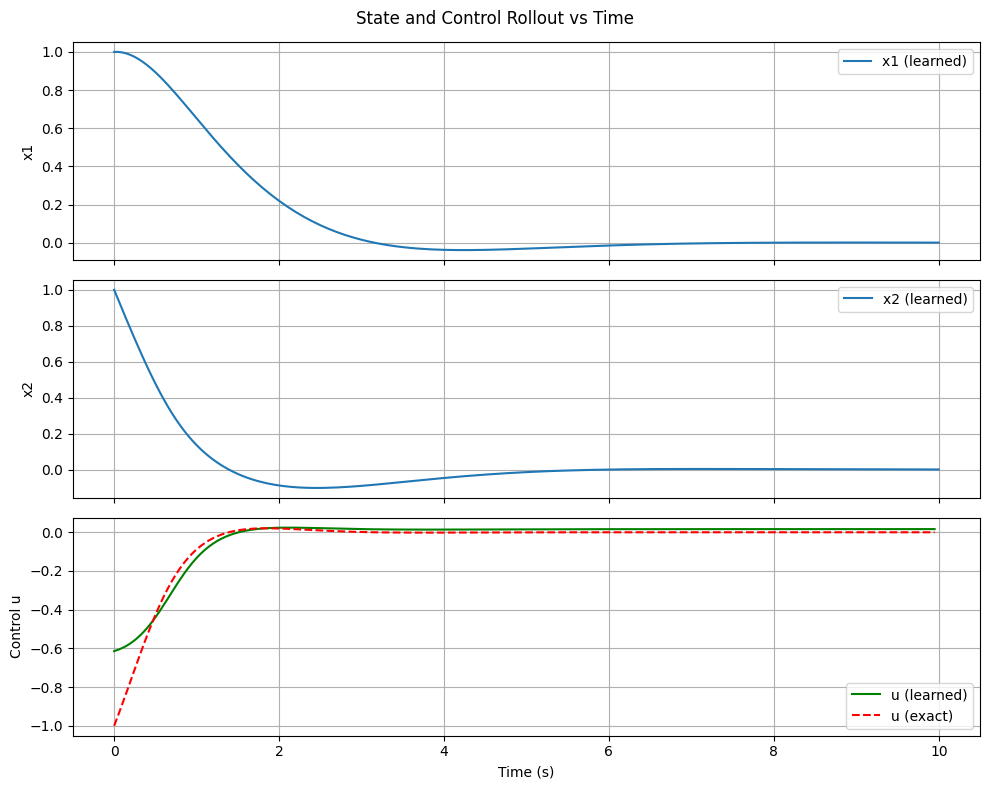

In [ ]:
import matplotlib.pyplot as plt

# Run a rollout from a test initial condition
x0 = torch.tensor([[1.0, 1.0]])  # starting point change as desired
T = 200  # number of timesteps
dt = 0.05

x = x0.clone()
xs = [x.detach().numpy()[0]]
us = []

for _ in range(T):
    with torch.no_grad():
        u = get_action(x, actor)
    f = p_dynamics(x, u)
    x = x + f * dt
    xs.append(x.detach().numpy()[0])
    us.append(u.detach().numpy()[0][0])

xs = np.array(xs)  # shape (T+1, 2)
us = np.array(us)  # shape (T,)
t_state = np.arange(T + 1) * dt
t_action = np.arange(T) * dt

# Exact solution for comparison
x_tensor = torch.tensor(xs, dtype=torch.float32)
u_exact_vals = u_exact(x_tensor[:-1]).detach().numpy().squeeze()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_state, xs[:, 0], label='x1 (learned)')
axes[0].set_ylabel('x1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_state, xs[:, 1], label='x2 (learned)')
axes[1].set_ylabel('x2')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_action, us, label='u (learned)', color='green')
axes[2].plot(t_action, u_exact_vals, label='u (exact)', color='red', linestyle='--')
axes[2].set_ylabel('Control u')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('State and Control Rollout vs Time')
plt.tight_layout()
plt.show()